# Phase 2 — Parsing, Cleaning & Exploratory Data Analysis (EDA)
This notebook parses the raw ball-by-ball match JSON files into a flat tabular format, cleans and handles edge cases, and constructs final match and ball-level parquet tables.


In [1]:
import os
import sys
import zipfile
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))
from src.common.config import RAW_DATA_DIR, INTERIM_DATA_DIR, FIGURES_DIR


## 1. Load Match Index
We load the match index created in Phase 1 to get the list of match IDs to process.


In [2]:
df_index = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'match_index.parquet'))
dls_matches_set = set(df_index[df_index['has_dls_applied'] == True]['match_id'])
revised_targets_dict = df_index.set_index('match_id')['dls_revised_target'].to_dict()
print(f'Match index loaded. Processing {len(df_index)} matches.')


Match index loaded. Processing 4801 matches.


## 2. Parse Match JSONs to Ball-by-ball Rows
We define a function that parses each JSON match file from the zip archive, handles wides, no-balls, retired hurts, excludes super overs, and extracts innings details.


In [3]:
def parse_ball_by_ball(zip_path, match_ids, competition_name):
    bbb_rows = []
    match_meta_rows = []
    dropped_counts = {'super_over': 0, 'abandoned': 0, 'parse_error': 0}
    
    with zipfile.ZipFile(zip_path, 'r') as archive:
        for match_id in match_ids:
            file_name = f'{match_id}.json'
            try:
                with archive.open(file_name) as f:
                    data = json.load(f)
                    info = data.get('info', {})
                    
                    dates = info.get('dates', [])
                    match_date = dates[0] if dates else None
                    venue = info.get('venue')
                    
                    outcome = info.get('outcome', {})
                    result = outcome.get('result')
                    if result in ['no result', 'abandoned'] or 'eliminated' in outcome:
                        dropped_counts['abandoned'] += 1
                        continue
                    
                    innings = data.get('innings', [])
                    if not innings:
                        dropped_counts['abandoned'] += 1
                        continue
                    
                    final_scores = {1: 0, 2: 0}
                    innings_count = 0
                    
                    for inn_data in innings:
                        if inn_data.get('super_over', False):
                            dropped_counts['super_over'] += 1
                            continue
                        
                        innings_count += 1
                        if innings_count > 2:
                            continue
                        
                        batting_team = inn_data.get('team')
                        teams = info.get('teams', [])
                        bowling_team = [t for t in teams if t != batting_team]
                        bowling_team = bowling_team[0] if bowling_team else None
                        
                        cumulative_score = 0
                        cumulative_wickets = 0
                        legal_balls_bowled = 0
                        
                        overs_list = inn_data.get('overs', [])
                        for over_data in overs_list:
                            over_no = over_data.get('over')
                            deliveries = over_data.get('deliveries', [])
                            
                            for ball_idx, deliv in enumerate(deliveries):
                                batter = deliv.get('batter')
                                bowler = deliv.get('bowler')
                                
                                runs_obj = deliv.get('runs', {})
                                runs_batter = runs_obj.get('batter', 0)
                                runs_extras = runs_obj.get('extras', 0)
                                total_runs_this_ball = runs_obj.get('total', 0)
                                
                                extras_obj = deliv.get('extras', {})
                                extra_type = None
                                if extras_obj:
                                    extra_type = list(extras_obj.keys())[0]
                                
                                wickets_list = deliv.get('wickets', [])
                                is_wicket = False
                                wicket_type = None
                                if wickets_list:
                                    wicket_obj = wickets_list[0]
                                    wicket_type = wicket_obj.get('kind')
                                    if wicket_type != 'retired hurt':
                                        is_wicket = True
                                
                                is_legal = extra_type not in ['wides', 'noballs']
                                if is_legal:
                                    legal_balls_bowled += 1
                                
                                cumulative_score += total_runs_this_ball
                                if is_wicket:
                                    cumulative_wickets += 1
                                
                                bbb_rows.append({
                                    'match_id': match_id,
                                    'innings_no': innings_count,
                                    'over': over_no,
                                    'ball_in_over': ball_idx + 1,
                                    'batting_team': batting_team,
                                    'bowling_team': bowling_team,
                                    'batsman': batter,
                                    'bowler': bowler,
                                    'runs_batter': runs_batter,
                                    'runs_extras': runs_extras,
                                    'extra_type': extra_type,
                                    'total_runs_this_ball': total_runs_this_ball,
                                    'is_wicket': is_wicket,
                                    'wicket_type': wicket_type,
                                    'cumulative_score': cumulative_score,
                                    'cumulative_wickets': cumulative_wickets,
                                    'legal_balls_bowled': legal_balls_bowled,
                                    'venue': venue,
                                    'date': match_date
                                })
                        
                        final_scores[innings_count] = cumulative_score
                    
                    match_meta_rows.append({
                        'match_id': match_id,
                        'competition': competition_name,
                        'teams': ', '.join(info.get('teams', [])),
                        'venue': venue,
                        'date': match_date,
                        'toss_winner': info.get('toss', {}).get('winner'),
                        'toss_decision': info.get('toss', {}).get('decision'),
                        'final_score_inn1': final_scores.get(1, 0),
                        'final_score_inn2': final_scores.get(2, 0),
                        'result': result,
                        'has_dls_applied': match_id in dls_matches_set,
                        'dls_revised_target': revised_targets_dict.get(match_id)
                    })
            except Exception as e:
                dropped_counts['parse_error'] += 1
                print(f'Error parsing {file_name}: {e}')
    print(f'Completed {competition_name} parsing: Dropped = {dropped_counts}')
    return bbb_rows, match_meta_rows, dropped_counts

ipl_ids = df_index[df_index['competition'] == 'IPL']['match_id']
t20i_ids = df_index[df_index['competition'] == 'T20I']['match_id']

ipl_bbb, ipl_meta, ipl_drops = parse_ball_by_ball(os.path.join(RAW_DATA_DIR, 'ipl_male_json.zip'), ipl_ids, 'IPL')
t20i_bbb, t20i_meta, t20i_drops = parse_ball_by_ball(os.path.join(RAW_DATA_DIR, 't20is_male_json.zip'), t20i_ids, 'T20I')

df_bbb = pd.DataFrame(ipl_bbb + t20i_bbb)
df_match_meta = pd.DataFrame(ipl_meta + t20i_meta)

df_bbb.to_parquet(os.path.join(INTERIM_DATA_DIR, 'ball_by_ball.parquet'), index=False)
df_match_meta.to_parquet(os.path.join(INTERIM_DATA_DIR, 'match_meta.parquet'), index=False)
print(f'Saved ball-by-ball records: {len(df_bbb)}')
print(f'Saved match metadata records: {len(df_match_meta)}')


Completed IPL parsing: Dropped = {'super_over': 34, 'abandoned': 9, 'parse_error': 0}


Completed T20I parsing: Dropped = {'super_over': 70, 'abandoned': 77, 'parse_error': 0}


Saved ball-by-ball records: 1090092
Saved match metadata records: 4715


## 3. Exploratory Data Analysis & Plots


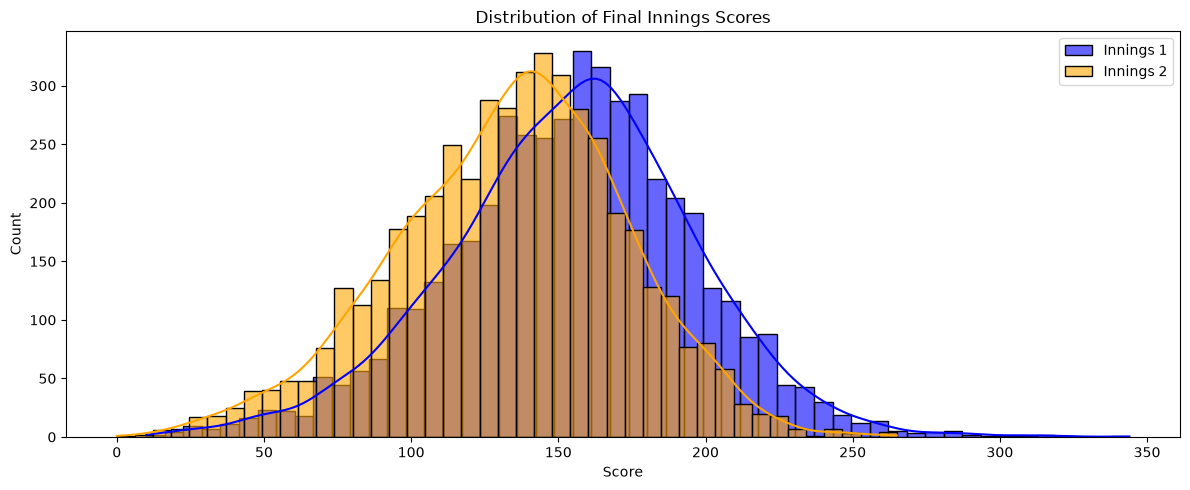

C:\Users\Tarun sharma\AppData\Local\Temp\ipykernel_13776\2288640613.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df_overs, x='over', y='cumulative_score', hue='innings_no', ci='sd')


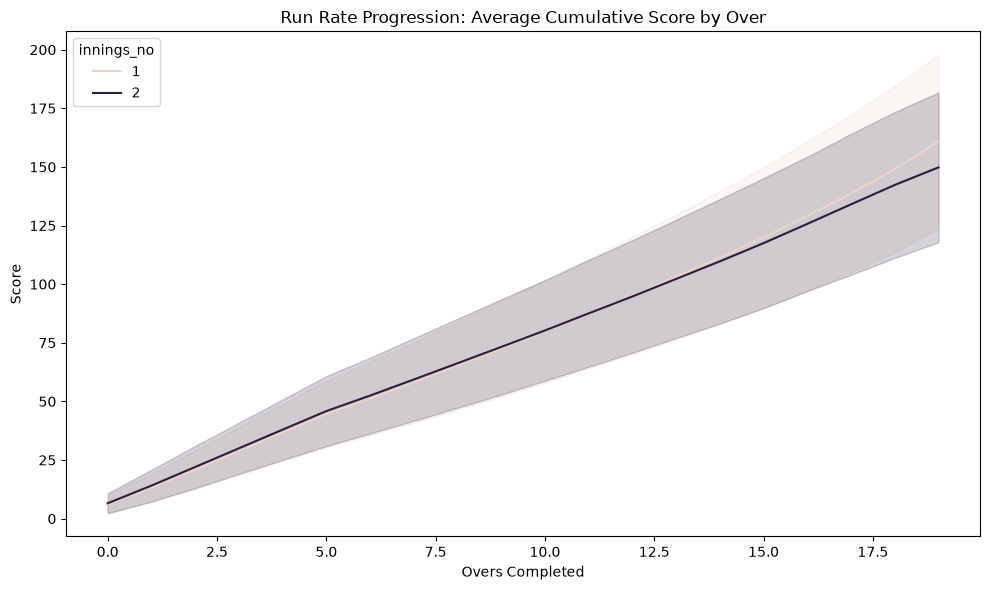

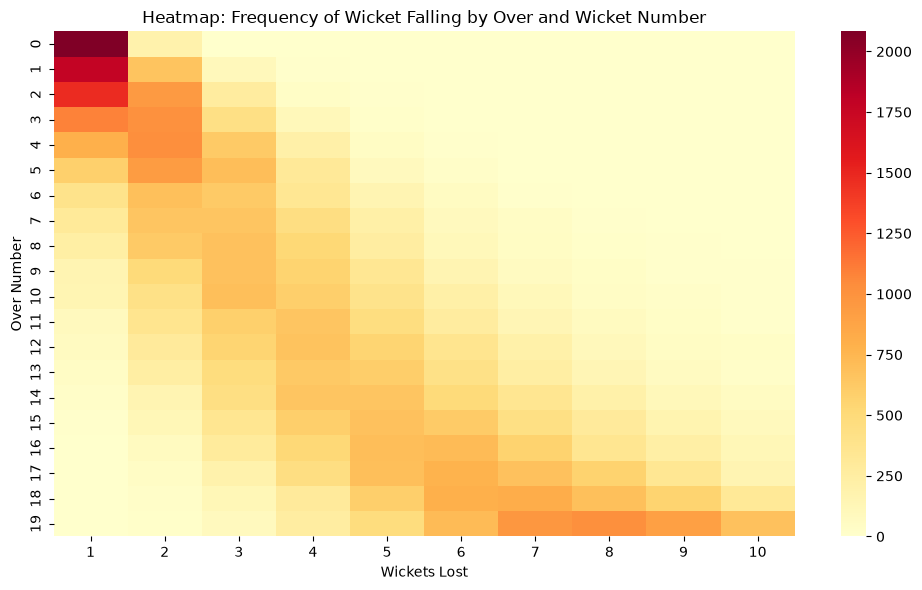

C:\Users\Tarun sharma\AppData\Local\Temp\ipykernel_13776\2288640613.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_venues, y='venue', x='final_score_inn1', palette='Set2')


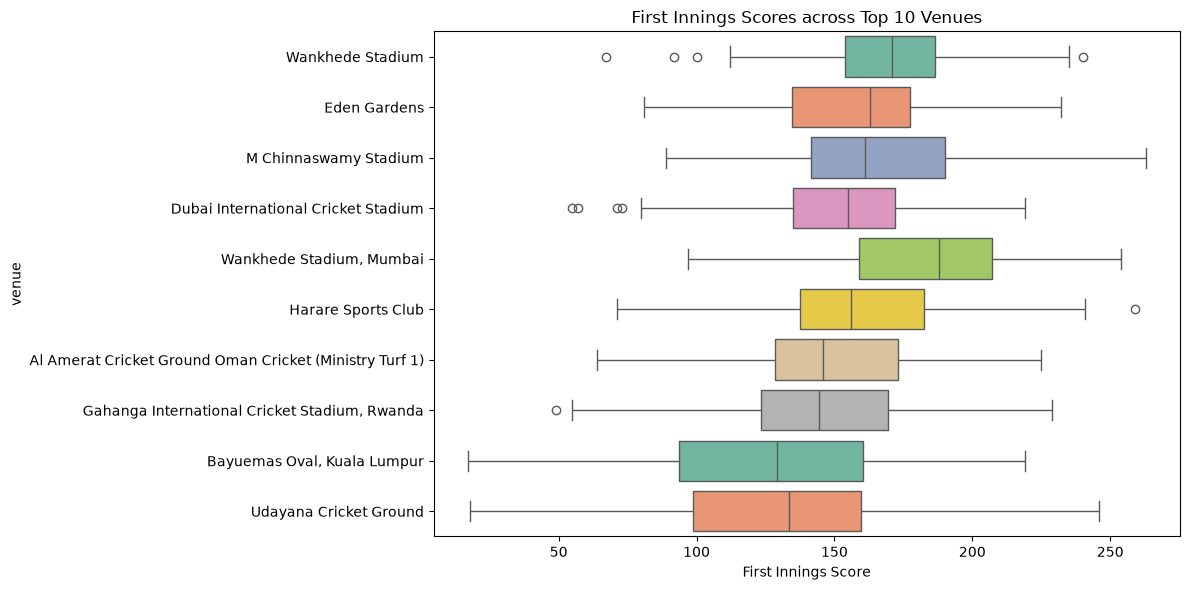

In [4]:
df_bbb = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'ball_by_ball.parquet'))
df_match_meta = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'match_meta.parquet'))

plt.figure(figsize=(12, 5))
sns.histplot(data=df_match_meta, x='final_score_inn1', kde=True, label='Innings 1', color='blue', alpha=0.6)
sns.histplot(data=df_match_meta, x='final_score_inn2', kde=True, label='Innings 2', color='orange', alpha=0.6)
plt.title('Distribution of Final Innings Scores')
plt.xlabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'final_scores_distribution.png'))
plt.show()

df_overs = df_bbb.groupby(['match_id', 'innings_no', 'over'])['cumulative_score'].max().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_overs, x='over', y='cumulative_score', hue='innings_no', ci='sd')
plt.title('Run Rate Progression: Average Cumulative Score by Over')
plt.xlabel('Overs Completed')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'score_progression_over.png'))
plt.show()

wicket_matrix = df_bbb[df_bbb['is_wicket'] == True].groupby(['over', 'cumulative_wickets']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(wicket_matrix, cmap='YlOrRd', annot=False)
plt.title('Heatmap: Frequency of Wicket Falling by Over and Wicket Number')
plt.xlabel('Wickets Lost')
plt.ylabel('Over Number')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'wicket_over_heatmap.png'))
plt.show()

top_venues = df_match_meta['venue'].value_counts().head(10).index
df_top_venues = df_match_meta[df_match_meta['venue'].isin(top_venues)]
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_venues, y='venue', x='final_score_inn1', palette='Set2')
plt.title('First Innings Scores across Top 10 Venues')
plt.xlabel('First Innings Score')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'venue_score_boxplot.png'))
plt.show()


## Summary & Conclusion
We have processed and cleaned the Cricsheet ball-by-ball logs into parquet tables. The EDA shows stable run-scoring profiles.
